In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to your file in Google Drive
file_path = '/content/drive/MyDrive/artikel_manual_pertamina.csv'

import pandas as pd
df = pd.read_csv(file_path)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Case ID,Case,Newsroom,Tanggal,Judul,Konten,Link,Tag,Tone
0,NaN,NaN,ylki.or.id,"June 8, 2016",Siaran Pers YLKI : Mendesak PT Pertamina untuk...,Kejadian kecurangan takaran pada SPBU yang ter...,https://ylki.or.id/siaran-pers-ylki-mendesak-p...,Hukum,Negatif
1,NaN,NaN,Kompas.com,6 Juli 2017,Pertamina Kembangkan Program Non-Tunai Pembeli...,"PONTIANAK, KOMPAS.com - PT Pertamina mensosial...",https://money.kompas.com/read/2017/07/06/14535...,BBM,Netral
2,NaN,NaN,Kompas.com,14 Desember 2017,"Pertamina Tak Masalahkan Nama Pertamini, tapi...","Nusa Dua, KompasOtomotif - Keberadaan kios-kio...",https://otomotif.kompas.com/read/2017/12/14/15...,Bisnis,Positif
3,NaN,NaN,Kompas.com,27 Juli 2017,Pertamina Patra Niaga Akan Bangun SPBU Skala U...,"JAKARTA, KOMPAS.com - PT Pertamina Patra Niaga...",https://money.kompas.com/read/2017/07/27/17565...,Bisnis,Positif
4,NaN,NaN,Kompas.com,18 Maret 2026,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Ju...","JAKARTA, KOMPAS.com - Situs pencari kerja, Job...",https://money.kompas.com/read/2016/03/18/14152...,Bisnis,Negatif


In [49]:

import pandas as pd

# Preview dataset
print("Dataset Shape:", df.shape)
df.head()

# Next Module: **3. Preprocessing Text Data**

Dataset Shape: (50, 9)


,Case ID,Case,Newsroom,Tanggal,Judul,Konten,Link,Tag,Tone
0,NaN,NaN,ylki.or.id,"June 8, 2016",Siaran Pers YLKI : Mendesak PT Pertamina untuk...,Kejadian kecurangan takaran pada SPBU yang ter...,https://ylki.or.id/siaran-pers-ylki-mendesak-p...,Hukum,Negatif
1,NaN,NaN,Kompas.com,6 Juli 2017,Pertamina Kembangkan Program Non-Tunai Pembeli...,"PONTIANAK, KOMPAS.com - PT Pertamina mensosial...",https://money.kompas.com/read/2017/07/06/14535...,BBM,Netral
2,NaN,NaN,Kompas.com,14 Desember 2017,"Pertamina Tak Masalahkan Nama Pertamini, tapi...","Nusa Dua, KompasOtomotif - Keberadaan kios-kio...",https://otomotif.kompas.com/read/2017/12/14/15...,Bisnis,Positif
3,NaN,NaN,Kompas.com,27 Juli 2017,Pertamina Patra Niaga Akan Bangun SPBU Skala U...,"JAKARTA, KOMPAS.com - PT Pertamina Patra Niaga...",https://money.kompas.com/read/2017/07/27/17565...,Bisnis,Positif
4,NaN,NaN,Kompas.com,18 Maret 2026,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Ju...","JAKARTA, KOMPAS.com - Situs pencari kerja, Job...",https://money.kompas.com/read/2016/03/18/14152...,Bisnis,Negatif


In [50]:
### 🔧 Implementation
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# Example: use only first article for demonstration
text = df['Konten'][0]


# Lowercase
text = text.lower()


# Remove punctuation & numbers
text = re.sub(r'[^a-zA-Z\s]', '', text)


# Tokenization
tokens = word_tokenize(text)


# Remove stopwords
stop_words = set(stopwords.words('indonesian'))
filtered_tokens = [w for w in tokens if w not in stop_words]


print("Original Text (shortened):", df['Konten'][0][:300])
print("\nProcessed Tokens:", filtered_tokens[:30])

Original Text (shortened): Kejadian kecurangan takaran pada SPBU yang terjadi di Rempoa, Ciputat, sesungguhnya bukan hal yang baru, banyak modus operandi yang dilakukan pengelola SPBU yang mengakibatkan kerugian konsumen. Sejak February 2016 YLKI telah mendapatkan informasi dari Direktur Jenderal Perlindungan Konsumen bahwa b

Processed Tokens: ['kejadian', 'kecurangan', 'takaran', 'spbu', 'rempoa', 'ciputat', 'sesungguhnya', 'modus', 'operandi', 'pengelola', 'spbu', 'mengakibatkan', 'kerugian', 'konsumen', 'february', 'ylki', 'informasi', 'direktur', 'jenderal', 'perlindungan', 'konsumen', 'berdasarkan', 'pantauan', 'bph', 'migas', 'spbu', 'wilayah', 'sumatera', 'yg', 'kecurangan']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# Example: Apply TF-IDF on the 'Content' column of your dataset
# (replace 'Content' with your actual column name if different)
documents = df['Konten'].astype(str).tolist()

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
dense = tfidf_matrix.todense()
denselist = dense.tolist()

# Create a DataFrame of TF-IDF scores
tfidf_df = pd.DataFrame(denselist, columns=feature_names)

print("Top TF-IDF Features across all documents:")
print(tfidf_df.sum().sort_values(ascending=False).head(20))

Top TF-IDF Features across all documents:
pertamina       17.087924
bbm              7.744950
energi           6.864225
spbu             6.015119
rp               5.756765
tangki           5.746533
program          5.206254
jakarta          4.532699
pt               4.464275
minyak           4.401319
perusahaan       4.400513
indonesia        4.114974
direktur         4.083759
nasional         3.918007
pt pertamina     3.773427
harga            3.552753
kapal            3.423433
masyarakat       3.390687
liter            3.294414
lingkungan       3.185545
dtype: float64


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [52]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords # Import stopwords

# Take the 'content' column for analysis
texts = df['Konten'].dropna().tolist()

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Create CountVectorizer for bigrams & trigrams
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words), max_features=10)
X = vectorizer.fit_transform(texts)

# Get top bigrams/trigrams
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = pd.DataFrame({'ngram': ngrams, 'count': counts}).sort_values(by='count', ascending=False)

ngram_freq

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


,ngram,count
8,pt pertamina,71
7,pertamina persero,44
9,pt pertamina persero,43
0,bahan bakar,32
3,mobil tangki,30
4,patra niaga,23
6,pertamina patra niaga,23
5,pertamina patra,23
1,direktur utama,21
2,energi nasional,20


## 5. Keyword Extraction

Now that we have preprocessed the text, we can explore different keyword extraction techniques to identify the most important terms in the articles.

### 5.1 TF-IDF (Term Frequency-Inverse Document Frequency)

We have already calculated the TF-IDF scores. We can use these scores to identify important keywords for each document or across the entire corpus.

### 5.2 TextRank

TextRank is a graph-based algorithm that can be used for keyword extraction. It is based on the idea that important words are those that are related to many other important words in the text.

### 5.3 RAKE (Rapid Automatic Keyword Extraction)

RAKE is another algorithm for keyword extraction that identifies keywords based on the frequency of words and the distance between them.

In [53]:
# Example: Extract keywords for the first document using TF-IDF
document_index = 0
tfidf_scores = tfidf_df.iloc[document_index]
sorted_keywords = tfidf_scores.sort_values(ascending=False)

print(f"Top TF-IDF keywords for document {document_index + 1}:")
print(sorted_keywords.head(10))

Top TF-IDF keywords for document 1:
spbu            0.930489
pt pertamina    0.214143
pt              0.209924
pertamina       0.179326
direktur        0.110033
harga           0.000000
bbm             0.000000
energi          0.000000
indonesia       0.000000
jakarta         0.000000
Name: 0, dtype: float64


## 6. Text Embeddings

Text embeddings are numerical representations of text that capture semantic meaning. We can use embeddings to analyze the similarity between documents or words.

### 6.1 Word Embeddings (e.g., Word2Vec, GloVe)

Word embeddings represent individual words as vectors.

### 6.2 Document Embeddings (e.g., Doc2Vec, Sentence-BERT)

Document embeddings represent entire documents as vectors.

### 6.3 Using Pre-trained Embeddings

We can use pre-trained embeddings to leverage knowledge from large datasets.

In [54]:
# Example: Placeholder for TextRank and RAKE implementation
print("Implementing TextRank and RAKE in the next steps...")

Implementing TextRank and RAKE in the next steps...


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# Example: Apply TF-IDF on the 'Content' column of your dataset
# (replace 'Content' with your actual column name if different)
documents = df['Konten'].astype(str).tolist()

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
dense = tfidf_matrix.todense()
denselist = dense.tolist()

# Create a DataFrame of TF-IDF scores
import pandas as pd
tfidf_df = pd.DataFrame(denselist, columns=feature_names)

print("Top TF-IDF Features across all documents:")
print(tfidf_df.sum().sort_values(ascending=False).head(20))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


Top TF-IDF Features across all documents:
pertamina       17.087924
bbm              7.744950
energi           6.864225
spbu             6.015119
rp               5.756765
tangki           5.746533
program          5.206254
jakarta          4.532699
pt               4.464275
minyak           4.401319
perusahaan       4.400513
indonesia        4.114974
direktur         4.083759
nasional         3.918007
pt pertamina     3.773427
harga            3.552753
kapal            3.423433
masyarakat       3.390687
liter            3.294414
lingkungan       3.185545
dtype: float64


In [56]:
import re
import pandas as pd
import nltk
from collections import Counter

nltk.download("punkt")

# Define lemma roots
lemmas = ["racun", "basi", "korban", "kejang"]

# Regex patterns to catch variations of each lemma
patterns = {lemma: re.compile(rf"\b\w*{lemma}\w*\b", re.IGNORECASE) for lemma in lemmas}

# Function: extract sentences + matched variations
def find_variations(text, patterns):
    if pd.isna(text):
        return []
    found = []
    sentences = nltk.sent_tokenize(text)
    for sent in sentences:
        for lemma, pattern in patterns.items():
            matches = pattern.findall(sent)
            if matches:
                found.append((lemma, sent.strip(), matches))
    return found

# Apply to dataset
df['lemma_sentences'] = df['Konten'].apply(lambda x: find_variations(x, patterns))

# Flatten results for frequency summary
all_matches = []
for row in df['lemma_sentences']:
    for lemma, sent, matches in row:
        all_matches.extend([(lemma, m.lower()) for m in matches])

# Count frequency per lemma root
lemma_counts = Counter([lemma for lemma, _ in all_matches])

# Count frequency per variation
variation_counts = Counter([match for _, match in all_matches])

# Convert to DataFrames for readability
df_lemma_summary = pd.DataFrame(lemma_counts.items(), columns=["lemma_root", "count"]).sort_values(by="count", ascending=False)
df_variation_summary = pd.DataFrame(variation_counts.items(), columns=["variation", "count"]).sort_values(by="count", ascending=False)

print("🔹 Frequency per Lemma Root:")
display(df_lemma_summary)

print("🔹 Frequency per Word Variation:")
display(df_variation_summary)

# Show sentences with matches (sample 5)
df_lemma_sentences = df[df['lemma_sentences'].str.len() > 0][['Judul', 'lemma_sentences']]
display(df_lemma_sentences.head(5))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


🔹 Frequency per Lemma Root:


,lemma_root,count
1,korban,7
0,basi,6


🔹 Frequency per Word Variation:


,variation,count
0,berbasis,5
1,korban,5
2,korbankan,1
3,korbannya,1
4,basis,1


,Judul,lemma_sentences
15,MIND ID - Pertamina Sinergi Percepat Hilirisas...,"[(basi, Hilirisasi berbasis teknologi menjadi ..."
17,Dihantam Cuaca Buruk Kapal Tangker Pertamina K...,"[(korban, Beruntung, dalam insiden yang menimp..."
22,"Didukung BPN-Kejaksaan, Pertamina Pulihkan Ase...","[(korban, ""Kementerian ATR mencoba menyelesaik..."
24,"HUT Ke-66, Pertamina Laksanakan Tiga Strategi ...","[(basi, RoadToHUT66 diawali dengan kegiatan Ko..."
32,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,"[(korban, Caya mengatakan total korban sampai ..."


In [57]:
import re
import pandas as pd
import nltk
from collections import Counter

nltk.download("punkt")

# Define lemma roots
lemmas = ["racun", "basi", "korban", "kejang"]

# Regex patterns to catch variations of each lemma
patterns = {lemma: re.compile(rf"\b\w*{lemma}\w*\b", re.IGNORECASE) for lemma in lemmas}

# Function: extract sentences + matched variations
def find_variations(text, patterns):
    if pd.isna(text):
        return []
    found = []
    sentences = nltk.sent_tokenize(text)
    for sent in sentences:
        for lemma, pattern in patterns.items():
            matches = pattern.findall(sent)
            if matches:
                found.append((lemma, sent.strip(), matches))
    return found

# Apply to dataset
df['lemma_sentences'] = df['Konten'].apply(lambda x: find_variations(x, patterns))

# --- 1) Lemma frequency summary ---
all_matches = []
for row in df['lemma_sentences']:
    for lemma, sent, matches in row:
        all_matches.extend([(lemma, m.lower()) for m in matches])

lemma_counts = Counter([lemma for lemma, _ in all_matches])
df_lemma_summary = pd.DataFrame(
    lemma_counts.items(), columns=["lemma_root", "count"]
).sort_values(by="count", ascending=False)

# --- 2) Variation frequency summary ---
variation_counts = Counter([match for _, match in all_matches])
df_variation_summary = pd.DataFrame(
    variation_counts.items(), columns=["variation", "count"]
).sort_values(by="count", ascending=False)

# --- 3) Sentence-level matches ---
rows = []
for i, row in df.iterrows():
    for lemma, sent, matches in row['lemma_sentences']:
        for m in matches:
            rows.append({
                "Judul": row['Judul'],
                "lemma_root": lemma,
                "match": m,
                "sentence": sent
            })

df_sentence_matches = pd.DataFrame(rows)


# df_lemma_summary
# df_variation_summary
# df_sentence_matches


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [58]:
df_lemma_summary

,lemma_root,count
1,korban,7
0,basi,6


In [59]:
df_variation_summary


,variation,count
0,berbasis,5
1,korban,5
2,korbankan,1
3,korbannya,1
4,basis,1


In [60]:
df_sentence_matches

,Judul,lemma_root,match,sentence
0,MIND ID - Pertamina Sinergi Percepat Hilirisas...,basi,berbasis,Hilirisasi berbasis teknologi menjadi instrume...
1,Dihantam Cuaca Buruk Kapal Tangker Pertamina K...,korban,korban,"Beruntung, dalam insiden yang menimpa kapal be..."
2,"Didukung BPN-Kejaksaan, Pertamina Pulihkan Ase...",korban,korbankan,"""Kementerian ATR mencoba menyelesaikan agar as..."
3,"HUT Ke-66, Pertamina Laksanakan Tiga Strategi ...",basi,berbasis,RoadToHUT66 diawali dengan kegiatan Komunitas ...
4,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,Caya mengatakan total korban sampai saat ini t...
5,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,"Menurutnya, para korban yang mengalami luka-lu..."
6,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,Ada pula korban yang sedang melintas dekat lok...
7,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,Korbannya,"""Korbannya beragam ada warga sekitar dan juga ..."
8,Viral Video Detik-detik Mengerikan Truk Pertam...,korban,korban,Tidak ada korban jiwa namun pengemudi mengalam...
9,Pertamina Dorong Pengembangan Energi Terbaruka...,basi,basis,Selain itu juga tercipta lapangan kerja untuk ...


In [61]:
df_sentence_matches.head()

,Judul,lemma_root,match,sentence
0,MIND ID - Pertamina Sinergi Percepat Hilirisas...,basi,berbasis,Hilirisasi berbasis teknologi menjadi instrume...
1,Dihantam Cuaca Buruk Kapal Tangker Pertamina K...,korban,korban,"Beruntung, dalam insiden yang menimpa kapal be..."
2,"Didukung BPN-Kejaksaan, Pertamina Pulihkan Ase...",korban,korbankan,"""Kementerian ATR mencoba menyelesaikan agar as..."
3,"HUT Ke-66, Pertamina Laksanakan Tiga Strategi ...",basi,berbasis,RoadToHUT66 diawali dengan kegiatan Komunitas ...
4,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,Caya mengatakan total korban sampai saat ini t...


In [62]:
# Explode matches into flat table
rows = []
for i, row in df.iterrows():
    for lemma, sent, matches in row['lemma_sentences']:
        for m in matches:
            rows.append({
                "Judul": row['Judul'],
                "lemma_root": lemma,
                "match": m,
                "sentence": sent
            })

df_matches = pd.DataFrame(rows)
display(df_matches.head(10))


,Judul,lemma_root,match,sentence
0,MIND ID - Pertamina Sinergi Percepat Hilirisas...,basi,berbasis,Hilirisasi berbasis teknologi menjadi instrume...
1,Dihantam Cuaca Buruk Kapal Tangker Pertamina K...,korban,korban,"Beruntung, dalam insiden yang menimpa kapal be..."
2,"Didukung BPN-Kejaksaan, Pertamina Pulihkan Ase...",korban,korbankan,"""Kementerian ATR mencoba menyelesaikan agar as..."
3,"HUT Ke-66, Pertamina Laksanakan Tiga Strategi ...",basi,berbasis,RoadToHUT66 diawali dengan kegiatan Komunitas ...
4,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,Caya mengatakan total korban sampai saat ini t...
5,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,"Menurutnya, para korban yang mengalami luka-lu..."
6,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,korban,Ada pula korban yang sedang melintas dekat lok...
7,Pertamina Indramayu: Kebakaran Tangki Penyimpa...,korban,Korbannya,"""Korbannya beragam ada warga sekitar dan juga ..."
8,Viral Video Detik-detik Mengerikan Truk Pertam...,korban,korban,Tidak ada korban jiwa namun pengemudi mengalam...
9,Pertamina Dorong Pengembangan Energi Terbaruka...,basi,basis,Selain itu juga tercipta lapangan kerja untuk ...


In [63]:
df_matches.shape

(13, 4)

In [64]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Use bigrams and trigrams
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words))
X = vectorizer.fit_transform(df['Konten'].dropna())

# Get all n-grams
ngrams = vectorizer.get_feature_names_out()

# Search for n-grams containing "beracun" or "korban"
target_terms = ["beracun", "korban"]
matches = [ng for ng in ngrams if any(term in ng for term in target_terms)]

print("N-grams containing 'beracun' or 'korban':")
print(matches)

N-grams containing 'beracun' or 'korban':
['berat menurutnya korban', 'caya total korban', 'gt korban', 'gt korban jiwa', 'hilang masyarakat korbankan', 'kebakaran korbannya', 'kebakaran korbannya beragam', 'kejadian korban', 'kejadian korban melintas', 'kelalaian pengemudi korban', 'korban jiwa', 'korban jiwa kebocoran', 'korban jiwa pengemudi', 'korban melintas', 'korban melintas lokasi', 'korban mengalami', 'korban mengalami luka', 'korban terdata', 'korban terdata 20', 'korbankan permasalahan', 'korbankan permasalahan sri', 'korbannya beragam', 'korbannya beragam warga', 'lokasi kebakaran korbannya', 'lokasi kejadian korban', 'masyarakat korbankan', 'masyarakat korbankan permasalahan', 'menurutnya korban', 'menurutnya korban mengalami', 'pengemudi korban', 'pengemudi korban jiwa', 'tonage gt korban', 'total korban', 'total korban terdata']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [65]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import pandas as pd

# Target lemma roots
target_terms = ["racun", "beracun", "basi", "korban", "kejang"]

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Use bigrams and trigrams
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words))
X = vectorizer.fit_transform(df['Konten'].dropna())

# Map n-grams to frequencies
ngram_counts = X.sum(axis=0).A1
ngram_freq = dict(zip(vectorizer.get_feature_names_out(), ngram_counts))

# Filter only those containing target terms
matches = {ng: count for ng, count in ngram_freq.items()
           if any(term in ng for term in target_terms)}

# Convert to DataFrame
df_ngram_matches = pd.DataFrame(matches.items(), columns=["ngram", "count"]) \
                    .sort_values(by="count", ascending=False)

print("🔹 N-grams containing target words:")
display(df_ngram_matches.head(15))


🔹 N-grams containing target words:


,ngram,count
29,korban jiwa,2
0,basis pemberdayaan,1
2,berat menurutnya korban,1
1,basis pemberdayaan komunitas,1
4,berbasis aplikasi menggandeng,1
5,berbasis digital,1
6,berbasis digital memanfaatkan,1
3,berbasis aplikasi,1
8,berbasis ict menjalankan,1
9,berbasis kolaborasi,1


In [66]:
# Split ngrams into individual tokens and explode into rows
df_ngram_split = df_ngram_matches.copy()
df_ngram_split["tokens"] = df_ngram_split["ngram"].str.split()

# Explode so each token gets its own row
df_ngram_split = df_ngram_split.explode("tokens").reset_index(drop=True)

display(df_ngram_split.head(15))


,ngram,count,tokens
0,korban jiwa,2,korban
1,korban jiwa,2,jiwa
2,basis pemberdayaan,1,basis
3,basis pemberdayaan,1,pemberdayaan
4,berat menurutnya korban,1,berat
5,berat menurutnya korban,1,menurutnya
6,berat menurutnya korban,1,korban
7,basis pemberdayaan komunitas,1,basis
8,basis pemberdayaan komunitas,1,pemberdayaan
9,basis pemberdayaan komunitas,1,komunitas


In [67]:
import pandas as pd

# Example: df_ngram_matches comes from your n-gram extraction step
# It has columns ["ngram", "count"]

# 1. Split into tokens
df_ngram_split = df_ngram_matches.copy()
df_ngram_split["tokens"] = df_ngram_split["ngram"].str.split()

# 2. Explode so each token is its own row
df_ngram_split = df_ngram_split.explode("tokens").reset_index(drop=True)

# 3. Summarize token frequency (weighted by n-gram count)
token_summary = (
    df_ngram_split.groupby("tokens")["count"]
    .sum()
    .reset_index()
    .sort_values(by="count", ascending=False)
)

# Show results
print("🔹 Split n-grams into rows:")
display(df_ngram_split.head(10))

print("🔹 Token frequency summary:")
display(token_summary.head(10))


🔹 Split n-grams into rows:


,ngram,count,tokens
0,korban jiwa,2,korban
1,korban jiwa,2,jiwa
2,basis pemberdayaan,1,basis
3,basis pemberdayaan,1,pemberdayaan
4,berat menurutnya korban,1,berat
5,berat menurutnya korban,1,menurutnya
6,berat menurutnya korban,1,korban
7,basis pemberdayaan komunitas,1,basis
8,basis pemberdayaan komunitas,1,pemberdayaan
9,basis pemberdayaan komunitas,1,komunitas


🔹 Token frequency summary:


,tokens,count
5,berbasis,25
23,korban,25
15,jiwa,6
24,korbankan,5
25,korbannya,5
2,basis,5
6,bisnis,4
38,pengemudi,4
1,aplikasi,3
18,kejadian,3


In [68]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are downloaded
nltk.download('stopwords')

# load dataset
#df used in here

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# ekstrak TF-IDF
vectorizer = TfidfVectorizer(stop_words=list(stop_words), max_features=20)
X = vectorizer.fit_transform(df["Konten"].dropna())
keywords = vectorizer.get_feature_names_out()

print("Kata kunci utama:", keywords)

Kata kunci utama: ['bbm' 'direktur' 'energi' 'harga' 'indonesia' 'jakarta' 'kapal'
 'lingkungan' 'liter' 'masyarakat' 'minyak' 'nasional' 'persero'
 'pertamina' 'perusahaan' 'program' 'pt' 'rp' 'spbu' 'tangki']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [69]:
!pip install python-rake -q

In [70]:
!pip install rake-nltk


In [71]:
from rake_nltk import Rake
import nltk
from nltk.corpus import stopwords
import pandas as pd

# Ensure stopwords are downloaded
nltk.download("stopwords")

# Initialize RAKE with Indonesian stopwords
stop_words = set(stopwords.words("indonesian"))
r = Rake(stopwords=list(stop_words))

# Function to extract RAKE keywords for a document
def extract_rake_keywords(text, top_n=10):
    if pd.isna(text):
        return []
    r.extract_keywords_from_text(text)
    return r.get_ranked_phrases_with_scores()[:top_n]

# Apply to all articles
df["rake_keywords"] = df["Konten"].apply(lambda x: extract_rake_keywords(x, top_n=10))

# Flatten results for analysis
all_rake_keywords = []
for idx, row in df.iterrows():
    for score, phrase in row["rake_keywords"]:
        all_rake_keywords.append({
            "doc_id": idx,
            "title": row["Judul"],
            "score": score,
            "keyword": phrase
        })

df_rake = pd.DataFrame(all_rake_keywords)

# Show results
print("🔹 Sample RAKE keywords per document:")
display(df[["Judul", "rake_keywords"]].head(5))

print("🔹 Flattened RAKE keyword table:")
display(df_rake.head(10))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🔹 Sample RAKE keywords per document:


,Judul,rake_keywords
0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,"[(16.0, berdasarkan pantauan bph migas), (15.5..."
1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"[(34.3, pt pertamina mensosialisasikan program..."
2,"Pertamina Tak Masalahkan Nama Pertamini, tapi...","[(108.17027417027418, beluk kios bbm eceran pe..."
3,Pertamina Patra Niaga Akan Bangun SPBU Skala U...,"[(78.92857142857143, anak usaha pt pertamina b..."
4,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Ju...","[(21.0, tren penurunan harga minyak dunia), (2..."


🔹 Flattened RAKE keyword table:


,doc_id,title,score,keyword
0,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,16.000000,berdasarkan pantauan bph migas
1,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,15.500000,direktur jenderal perlindungan konsumen
2,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,9.500000,mengakibatkan kerugian konsumen
3,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,9.000000,wilayah sumatera yg
4,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,9.000000,ranah meja hijau
5,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,9.000000,diputus kontrak kemitraannya
6,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,9.000000,daftar black list
7,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,8.500000,february 2016 ylki
8,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,7.857143,minimal pimpinan spbu
9,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,7.750000,kejadian kecurangan takaran


In [72]:
df_rake.shape

(500, 4)

In [73]:
!pip install sumy

In [74]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

# Initialize TextRank
summarizer = TextRankSummarizer()

# Function to extract TextRank key sentences or phrases
def extract_textrank_keywords(text, top_n=5):
    if pd.isna(text) or not isinstance(text, str):
        return []
    try:
        parser = PlaintextParser.from_string(text, Tokenizer("indonesian"))
    except LookupError:
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
    summary = summarizer(parser.document, top_n)
    return [str(sentence) for sentence in summary]


# Apply to all articles
df["textrank_keywords"] = df["Konten"].apply(lambda x: extract_textrank_keywords(x, top_n=5))

# Flatten results into table
all_textrank_keywords = []
for idx, row in df.iterrows():
    for phrase in row["textrank_keywords"]:
        all_textrank_keywords.append({
            "doc_id": idx,
            "title": row["Judul"],
            "keyword": phrase
        })

df_textrank = pd.DataFrame(all_textrank_keywords)

# Show results
print("🔹 Sample TextRank keywords per document:")
display(df[["Judul", "textrank_keywords"]].head(5))

print("🔹 Flattened TextRank keyword table:")
display(df_textrank.head(10))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


🔹 Sample TextRank keywords per document:


,Judul,textrank_keywords
0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,[Kejadian kecurangan takaran pada SPBU yang te...
1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"[PONTIANAK, KOMPAS.com - PT Pertamina mensosia..."
2,"Pertamina Tak Masalahkan Nama Pertamini, tapi...",[Berbeda dengan kios-kios biasa yang menggunak...
3,Pertamina Patra Niaga Akan Bangun SPBU Skala U...,"[JAKARTA, KOMPAS.com - PT Pertamina Patra Niag..."
4,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Ju...","[Di tengah melemahnya harga minyak, perusahaan..."


🔹 Flattened TextRank keyword table:


,doc_id,title,keyword
0,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,Kejadian kecurangan takaran pada SPBU yang ter...
1,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,PERTAMINA (Persero) pada bulan Maret yang lalu...
2,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,PERTAMINA (Persero) segera melakukan pengawasa...
3,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,Agar PT Pertamina memberikan sanksi tegas pada...
4,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,Namun demikian bukan hanya pada pelaku lapanga...
5,1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"PONTIANAK, KOMPAS.com - PT Pertamina mensosial..."
6,1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"Sales Eksekutif BBM Pertamina Pontianak, Arwin..."
7,1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"""Tapi yang saat ini untuk tahap awal sosialisa..."
8,1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"Saat ini, seluruh SPBU yang ada di Pontianak s..."
9,1,Pertamina Kembangkan Program Non-Tunai Pembeli...,Uang elektronik di SPBU ini akan mulai diberla...


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# Get Indonesian stopwords from NLTK
stop_words = stopwords.words("indonesian")

vectorizer = TfidfVectorizer(max_features=10, stop_words=stop_words)
X = vectorizer.fit_transform(df["Konten"].fillna(""))

tfidf_feature_names = vectorizer.get_feature_names_out()

def extract_tfidf_keywords(doc_index, top_n=5):
    row = X[doc_index].toarray().flatten()
    top_indices = row.argsort()[::-1][:top_n]
    return [tfidf_feature_names[i] for i in top_indices if row[i] > 0]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [76]:
# ✅ Install needed packages
!pip install rake-nltk sumy openpyxl

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from rake_nltk import Rake
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
import pandas as pd

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# --- 1. TF-IDF Setup ---
stop_words = stopwords.words("indonesian")
vectorizer = TfidfVectorizer(max_features=50, stop_words=stop_words)
X = vectorizer.fit_transform(df["Konten"].fillna(""))
tfidf_feature_names = vectorizer.get_feature_names_out()

def extract_tfidf_keywords(doc_index, top_n=5):
    row = X[doc_index].toarray().flatten()
    top_indices = row.argsort()[::-1][:top_n]
    return [tfidf_feature_names[i] for i in top_indices if row[i] > 0]

# --- 2. RAKE Setup ---
r = Rake(stopwords=stop_words)

def extract_rake_keywords(text, top_n=5):
    if pd.isna(text):
        return []
    r.extract_keywords_from_text(text)
    return [phrase for score, phrase in r.get_ranked_phrases_with_scores()[:top_n]]

# --- 3. TextRank Setup ---
summarizer = TextRankSummarizer()

def extract_textrank_keywords(text, top_n=3):
    if pd.isna(text) or not isinstance(text, str):
        return []
    try:
        parser = PlaintextParser.from_string(text, Tokenizer("indonesian"))
    except LookupError:
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
    summary = summarizer(parser.document, top_n)
    return [str(sentence) for sentence in summary]

# --- 4. Apply all methods to ALL documents ---
comparison_results = []
tfidf_results = []
rake_results = []
textrank_results = []

for idx in range(len(df)):
    text = df.loc[idx, "Konten"]
    title = df.loc[idx, "Judul"]

    tfidf_kw = extract_tfidf_keywords(idx, top_n=5)
    rake_kw = extract_rake_keywords(text, top_n=5)
    textrank_kw = extract_textrank_keywords(text, top_n=3)

    comparison_results.append({
        "doc_id": idx,
        "title": title,
        "TF-IDF": tfidf_kw,
        "RAKE": rake_kw,
        "TextRank": textrank_kw
    })

    for kw in tfidf_kw:
        tfidf_results.append({"doc_id": idx, "title": title, "keyword": kw})
    for kw in rake_kw:
        rake_results.append({"doc_id": idx, "title": title, "keyword": kw})
    for kw in textrank_kw:
        textrank_results.append({"doc_id": idx, "title": title, "keyword": kw})

# DataFrames
df_comparison = pd.DataFrame(comparison_results)
df_tfidf = pd.DataFrame(tfidf_results)
df_rake = pd.DataFrame(rake_results)
df_textrank = pd.DataFrame(textrank_results)

# --- 5. Export to Excel with multiple sheets ---
output_file = "pertamina_keywords_comparison.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_tfidf.to_excel(writer, sheet_name="TF-IDF", index=False)
    df_rake.to_excel(writer, sheet_name="RAKE", index=False)
    df_textrank.to_excel(writer, sheet_name="TextRank", index=False)
    df_comparison.to_excel(writer, sheet_name="Comparison", index=False)

print(f"✅ Exported all results to {output_file}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Exported all results to pertamina_keywords_comparison.xlsx


In [77]:
df_comparison

,doc_id,title,TF-IDF,RAKE,TextRank
0,0,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,"[spbu, pt, pertamina, persero, migas]","[berdasarkan pantauan bph migas, direktur jend...",[Kejadian kecurangan takaran pada SPBU yang te...
1,1,Pertamina Kembangkan Program Non-Tunai Pembeli...,"[program, spbu, 000, rp, bbm]",[pt pertamina mensosialisasikan program penggu...,"[PONTIANAK, KOMPAS.com - PT Pertamina mensosia..."
2,2,"Pertamina Tak Masalahkan Nama Pertamini, tapi...","[pertamina, bahan, bakar, meningkatkan, tangki]",[beluk kios bbm eceran pertamini head of marke...,[Berbeda dengan kios-kios biasa yang menggunak...
3,3,Pertamina Patra Niaga Akan Bangun SPBU Skala U...,"[spbu, bbm, 000, pertamina, patra]",[anak usaha pt pertamina berencana membangun s...,"[JAKARTA, KOMPAS.com - PT Pertamina Patra Niag..."
4,4,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Ju...","[migas, perusahaan, juta, rp, harga]","[tren penurunan harga minyak dunia, tingkat ke...","[Di tengah melemahnya harga minyak, perusahaan..."
5,5,Dirut dan Wadirut Pertamina Resmi Dicopot,"[pertamina, negara, utama, direktur, perusahaan]","[com — kementerian badan usaha milik negara, d...","[""Mulai hari ini (keduanya) diberhentikan sesu..."
6,6,Pertamina Jamin Stok BBM Jelang Mudik 2017,"[bbm, truk, mobil, 10, jakarta]","[menambah armada mobil tangki beserta awaknya,...","[Hal ini berlaku untuk semua jenis BBM, baik s..."
7,7,BBM Kemasan Pertamina Tanpa Terima Pesanan,"[bbm, liter, mobil, pertamina, 10]","[pertamina menyediakan 83 unit sepeda motor, m...","[Beberapa skenario sudah dibuat, bahkan sampai..."
8,8,Pertamina Siapkan BBM Kemasan Satu dan Dua Liter,"[bbm, truk, liter, spbu, harga]",[area manager communication and relation jbb m...,[Jadi bila di SPBU habis truk ini akan berpera...
9,9,"Jaga Pasokan Energi, Pertamina Perkuat Monitor...","[pertamina, energi, spbu, produk, nasional]",[vice president corporate communication pt per...,"[Jakarta, CNN Indonesia -- PT Pertamina (Perse..."


## 6. Text Embeddings

Text embeddings are numerical representations of text that capture semantic meaning. We can use embeddings to analyze the similarity between documents or words.

### 6.1 Using Pre-trained Embeddings

We can use pre-trained embeddings to leverage knowledge from large datasets. Sentence-BERT is a popular choice for generating sentence and document embeddings.

In [78]:
!pip install sentence-transformers -q

In [79]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence-BERT model
# Using a multilingual model that supports Indonesian
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generate embeddings for the 'Konten' column
# Handle potential NaN values by converting to string
sentences = df['Konten'].astype(str).tolist()
embeddings = model.encode(sentences)

print("Shape of embeddings:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of embeddings: (50, 384)


Now that we have the embeddings, we can use them for various downstream tasks, such as:

- **Document Similarity:** Calculate the similarity between articles.
- **Clustering:** Group similar articles together.
- **Visualization:** Visualize the embeddings to see relationships between articles.

In [80]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Convert to a DataFrame for better readability
similarity_df = pd.DataFrame(similarity_matrix, index=df['Judul'], columns=df['Judul'])

print("Cosine Similarity Matrix (first 5 rows and columns):")
display(similarity_df.head())

# You can also find the most similar documents to a specific document
# Example: Find most similar documents to the first document
document_index_to_compare = 0
similarity_scores = similarity_df.iloc[document_index_to_compare].sort_values(ascending=False)

print(f"\nMost similar documents to '{df['Judul'][document_index_to_compare]}':")
# Display top 6, excluding the document itself (similarity score of 1)
display(similarity_scores.head(6))

Cosine Similarity Matrix (first 5 rows and columns):


Judul,Siaran Pers YLKI : Mendesak PT Pertamina untuk Perketat Pengawasan SPBU,Pertamina Kembangkan Program Non-Tunai Pembelian BBM di SPBU,"Pertamina Tak Masalahkan Nama Pertamini, tapi...",Pertamina Patra Niaga Akan Bangun SPBU Skala UKM di Berbagai Pelosok,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Juta, di Pertamina Rp 13,3 Juta per Bulan\r\n",Dirut dan Wadirut Pertamina Resmi Dicopot,Pertamina Jamin Stok BBM Jelang Mudik 2017,BBM Kemasan Pertamina Tanpa Terima Pesanan,Pertamina Siapkan BBM Kemasan Satu dan Dua Liter,"Jaga Pasokan Energi, Pertamina Perkuat Monitoring lewat Digital Hub",...,"62 Tahun Usia Pertamina, Apa yang Telah Diberikan untuk Tanah Air?",Dirut Pertamina Terpilih Jadi TOP Leader in IT Leadership 2018,Pertamina Setor ke Negara Rp 120 Triliun di 2018,Pertamina akan Bahas Potensi Energi Dalam Negeri di PEF 2018,Pertamina MOR III Raih Patra Nirbaya Karya Pratama,"Korupsi Rp 612 M, Eks Presdir Dana Pensiun Pertamina Dibui 8 Tahun","Divonis 8 Tahun Bui, Eks Dirkeu Pertamina Sebut Hakim Abaikan Fakta","Totem SPBU Medan Diretas, Ini Penjelasan Pertamina","Gaji Direksi dan Komisaris Rp 3,2 Miliar Per Bulan, Ini Kata Pertamina","Direksi Pertamina Kembali Dirombak, Dirut dan 4 Direktur Dicopot"
Judul,,,,,,,,,,,,,,,,,,,,,
Siaran Pers YLKI : Mendesak PT Pertamina untuk Perketat Pengawasan SPBU,1.000000,0.536759,0.315723,0.440310,0.451505,0.534415,0.557734,0.478986,0.443185,0.460873,...,0.429994,0.360236,0.512744,0.332728,0.556797,0.403645,0.331689,0.520415,0.480424,0.517441
Pertamina Kembangkan Program Non-Tunai Pembelian BBM di SPBU,0.536759,1.000000,0.463539,0.632849,0.438267,0.573116,0.742705,0.679897,0.664735,0.611319,...,0.523859,0.440635,0.592760,0.560372,0.485160,0.266999,0.230729,0.455255,0.510342,0.476020
"Pertamina Tak Masalahkan Nama Pertamini, tapi...",0.315723,0.463539,1.000000,0.417988,0.274355,0.488601,0.505132,0.530472,0.496407,0.472918,...,0.387947,0.295630,0.412697,0.365577,0.315715,0.082187,0.047469,0.138876,0.257536,0.344119
Pertamina Patra Niaga Akan Bangun SPBU Skala UKM di Berbagai Pelosok,0.440310,0.632849,0.417988,1.000000,0.421354,0.675482,0.635004,0.591110,0.643907,0.672387,...,0.542672,0.564543,0.620971,0.710249,0.615892,0.170502,0.168369,0.350511,0.424236,0.587346
"Gaji Manajer 'Engineering' Chevron Rp 51,25 Juta, di Pertamina Rp 13,3 Juta per Bulan\r\n",0.451505,0.438267,0.274355,0.421354,1.000000,0.334096,0.412714,0.422536,0.323620,0.257408,...,0.317469,0.328073,0.480733,0.319540,0.487935,0.213155,0.123577,0.153647,0.492085,0.266363



Most similar documents to 'Siaran Pers YLKI : Mendesak PT Pertamina untuk Perketat Pengawasan SPBU':


,Siaran Pers YLKI : Mendesak PT Pertamina untuk Perketat Pengawasan SPBU
Judul,
Siaran Pers YLKI : Mendesak PT Pertamina untuk Perketat Pengawasan SPBU,1.000000
"BBM Langka di Medan, Ombudsman Sebut Mitigasi Pertamina Buruk",0.608881
"Hadirkan Energi ke Pelosok Negeri, Pertamina Patra Niaga Berkomitmen Tambah Titik BBM Satu Harga",0.593879
Pertamina Dorong Pengembangan Energi Terbarukan melalui Program Energi Berdikari,0.558962
Pertamina Jamin Stok BBM Jelang Mudik 2017,0.557734
Pertamina MOR III Raih Patra Nirbaya Karya Pratama,0.556797


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (50, 384)


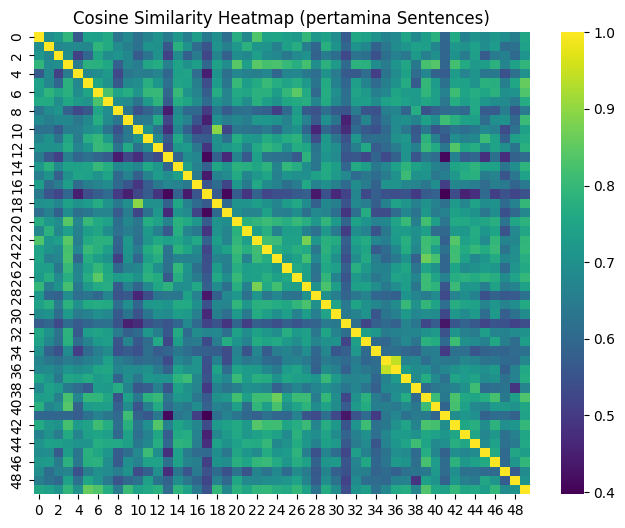

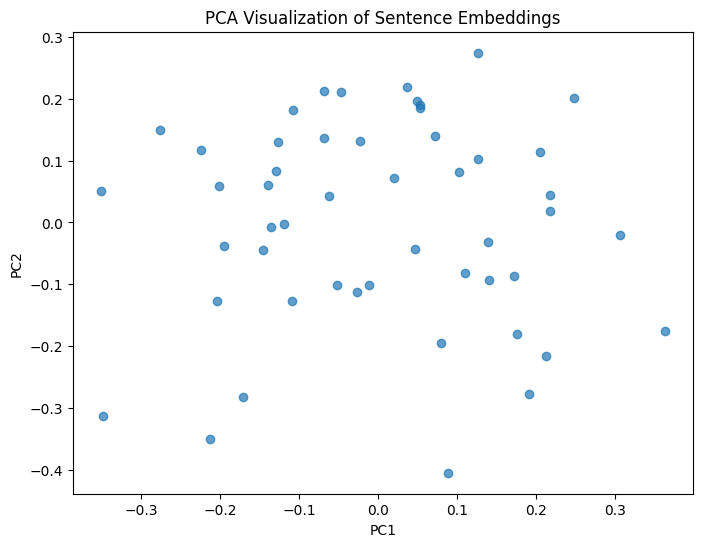

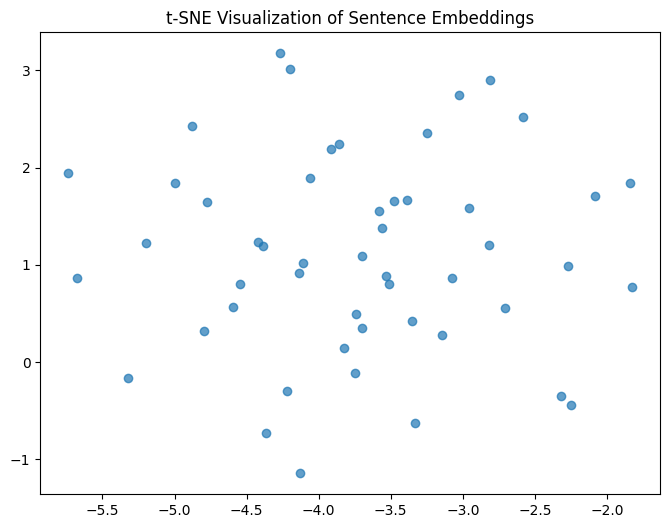

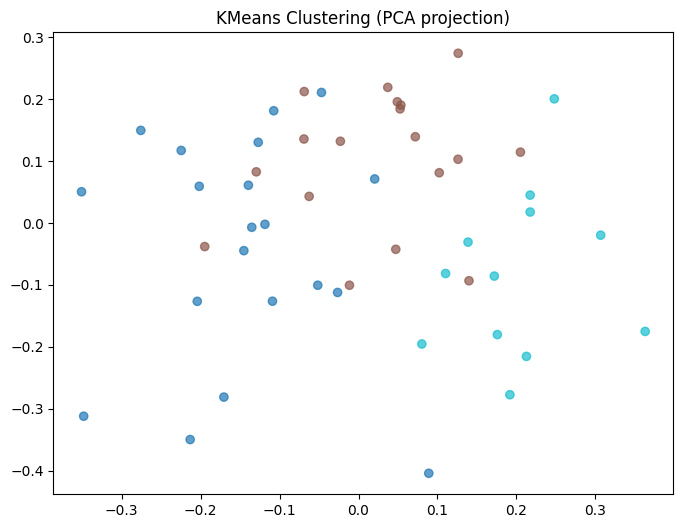


Cluster 0 examples:
['PONTIANAK, KOMPAS.com - PT Pertamina mensosialisasikan program penggunaan uang elektronik untuk transaksi pembelian bahan bakar di setiap SPBU yang ada di seluruh kota Pontianak, Kalimantan Barat, Rabu (5/7/2017). Sosialisasi tersebut dihadiri sejumlah lembaga perbankan yang bekerjasama dengan Pertamina dalam program cashless tersebut. Sales Eksekutif BBM Pertamina Pontianak, Arwin Nugraha mengatakan, rencananya seluruh SPBU yang ada di Pontianak mulai tanggal 1 Januari 2018, untuk pembelian BBM sudah harus menggunakan uang elektronik (non tunai) ini. "Saat ini kita bekerja sama dengan Bank Indonesia maupun Hiswana Migas untuk mempersiapkan sarana dan prasarana pendukung, serta mengkampanyekan kepada masyarakat untuk menggunakan uang elektronik," ujar Arwin usai Kick Off SPBU Cashless di Hotel Grand Tulip, Rabu (5/7/2017). Saat ini, ungkap Arwin, sejumlah bank yang sebelumnya sudah mempunyai program uang elektronik seperti BCA, BRI, Mandiri atau bank lainnya. "Ta

In [81]:
# --- 1. Install dependencies (if needed) ---
# pip install sentence-transformers scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# --- 2. Load pertamina dataset ---
# assuming df['Konten'] already exists
sentences = df['Konten'].dropna().tolist()

# --- 3. Generate embeddings ---
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)
# Example: (N_sentences, 384)

# --- 4. Cosine Similarity Heatmap ---
cos_sim = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(cos_sim, cmap="viridis")
plt.title("Cosine Similarity Heatmap (pertamina Sentences)")
plt.show()

# --- 5. PCA Visualization ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.7)
plt.title("PCA Visualization of Sentence Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# --- 6. t-SNE Visualization ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(tsne_result[:,0], tsne_result[:,1], alpha=0.7)
plt.title("t-SNE Visualization of Sentence Embeddings")
plt.show()

# --- 7. KMeans Clustering ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

df['Cluster'] = labels  # add results back to DataFrame

# Visualize clusters with PCA
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap="tab10", alpha=0.7)
plt.title("KMeans Clustering (PCA projection)")
plt.show()

# --- 8. Inspect cluster examples ---
for cluster_id in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster_id} examples:")
    print(df[df['Cluster']==cluster_id]['Konten'].head(3).tolist())



Cluster 0 → Challenge
['PONTIANAK, KOMPAS.com - PT Pertamina mensosialisasikan program penggunaan uang elektronik untuk transaksi pembelian bahan bakar di setiap SPBU yang ada di seluruh kota Pontianak, Kalimantan Barat, Rabu (5/7/2017). Sosialisasi tersebut dihadiri sejumlah lembaga perbankan yang bekerjasama dengan Pertamina dalam program cashless tersebut. Sales Eksekutif BBM Pertamina Pontianak, Arwin Nugraha mengatakan, rencananya seluruh SPBU yang ada di Pontianak mulai tanggal 1 Januari 2018, untuk pembelian BBM sudah harus menggunakan uang elektronik (non tunai) ini. "Saat ini kita bekerja sama dengan Bank Indonesia maupun Hiswana Migas untuk mempersiapkan sarana dan prasarana pendukung, serta mengkampanyekan kepada masyarakat untuk menggunakan uang elektronik," ujar Arwin usai Kick Off SPBU Cashless di Hotel Grand Tulip, Rabu (5/7/2017). Saat ini, ungkap Arwin, sejumlah bank yang sebelumnya sudah mempunyai program uang elektronik seperti BCA, BRI, Mandiri atau bank lainnya. "

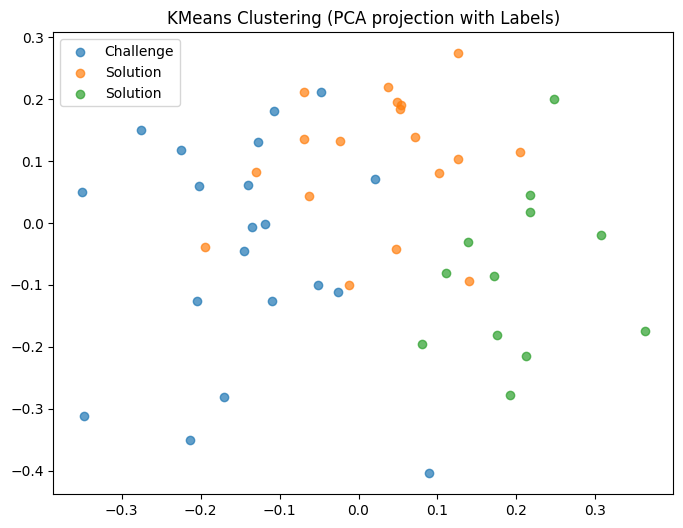

In [82]:
# --- 7. KMeans Clustering ---
from collections import Counter

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

df['Cluster'] = labels  # add results back to DataFrame

# --- 8. Heuristic Cluster Labeling ---
# Define simple keyword sets (you can adjust based on your pertamina dataset)
keywords_map = {
    "Challenge": ["masalah", "tantangan", "hambatan", "kesulitan", "kurang", "gagal"],
    "Solution": ["solusi", "program", "inisiatif", "kebijakan", "strategi", "dukungan"],
    "Impact": ["ekonomi", "dampak", "manfaat", "pengaruh", "hasil", "perubahan"]
}

cluster_labels = {}

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_texts = " ".join(df[df['Cluster']==cluster_id]['Konten'].tolist()).lower()

    scores = {label: sum(word in cluster_texts for word in words)
              for label, words in keywords_map.items()}

    best_label = max(scores, key=scores.get) if any(scores.values()) else "Other"
    cluster_labels[cluster_id] = best_label

# Map cluster numbers → descriptive labels
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# --- 9. Inspect cluster examples ---
for cluster_id, label in cluster_labels.items():
    print(f"\nCluster {cluster_id} → {label}")
    print(df[df['Cluster']==cluster_id]['Konten'].head(3).tolist())

# --- 10. Visualize with descriptive labels ---
plt.figure(figsize=(8,6))
for cluster_id, label in cluster_labels.items():
    mask = df['Cluster'] == cluster_id
    plt.scatter(pca_result[mask,0], pca_result[mask,1], label=label, alpha=0.7)

plt.title("KMeans Clustering (PCA projection with Labels)")
plt.legend()
plt.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


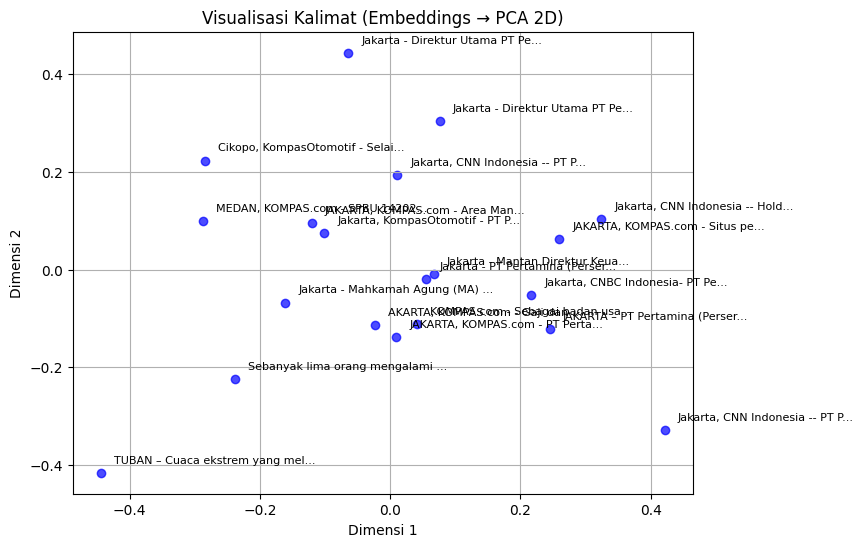

In [83]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 1. Ambil beberapa contoh kalimat (supaya plot tidak terlalu padat) ---
sample_sentences = df['Konten'].dropna().sample(20, random_state=42).tolist()

# --- 2. Buat embeddings ---
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sample_sentences)

# --- 3. Reduksi dimensi ke 2D (PCA) ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

# --- 4. Plot ---
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue", alpha=0.7)

for i, text in enumerate(sample_sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:30]+"...", fontsize=8)

plt.title("Visualisasi Kalimat (Embeddings → PCA 2D)")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


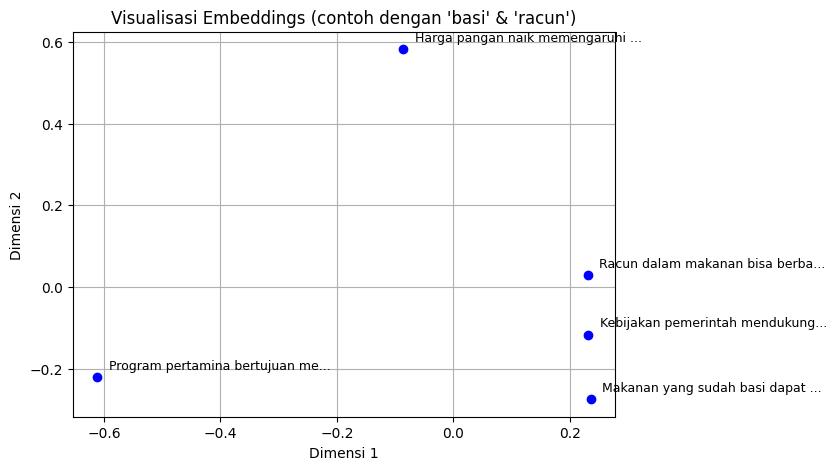

In [84]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sentences = [
    "Makanan yang sudah basi dapat menimbulkan penyakit.",
    "Racun dalam makanan bisa berbahaya bagi kesehatan.",
    "Program pertamina bertujuan meningkatkan gizi anak-anak.",
    "Kebijakan pemerintah mendukung distribusi makanan gratis.",
    "Harga pangan naik memengaruhi kondisi ekonomi keluarga."
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue")

for i, text in enumerate(sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:30]+"...", fontsize=9)

plt.title("Visualisasi Embeddings (contoh dengan 'basi' & 'racun')")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()


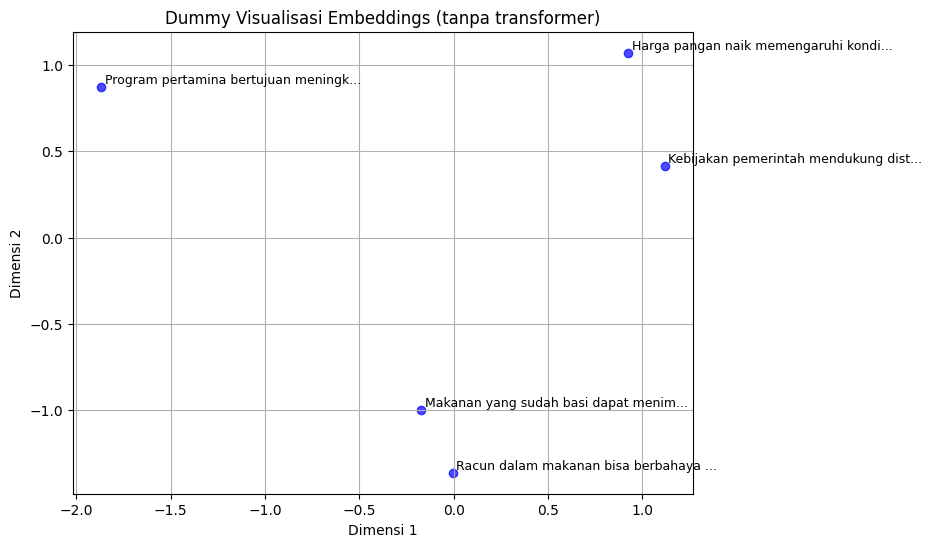

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- 1. Contoh kalimat (campuran manual + topik pertamina) ---
sentences = [
    "Makanan yang sudah basi dapat menimbulkan penyakit.",
    "Racun dalam makanan bisa berbahaya bagi kesehatan.",
    "Program pertamina bertujuan meningkatkan gizi anak-anak.",
    "Kebijakan pemerintah mendukung distribusi makanan gratis.",
    "Harga pangan naik memengaruhi kondisi ekonomi keluarga."
]

# --- 2. Buat dummy embeddings (random tapi stabil dengan seed) ---
np.random.seed(42)
embeddings = np.random.rand(len(sentences), 50)  # 50 dimensi dummy

# --- 3. Reduksi dimensi ke 2D (PCA) ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

# --- 4. Plot hasil ---
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue", alpha=0.7)

for i, text in enumerate(sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:35]+"...", fontsize=9)

plt.title("Dummy Visualisasi Embeddings (tanpa transformer)")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ukuran embeddings: (5, 384)


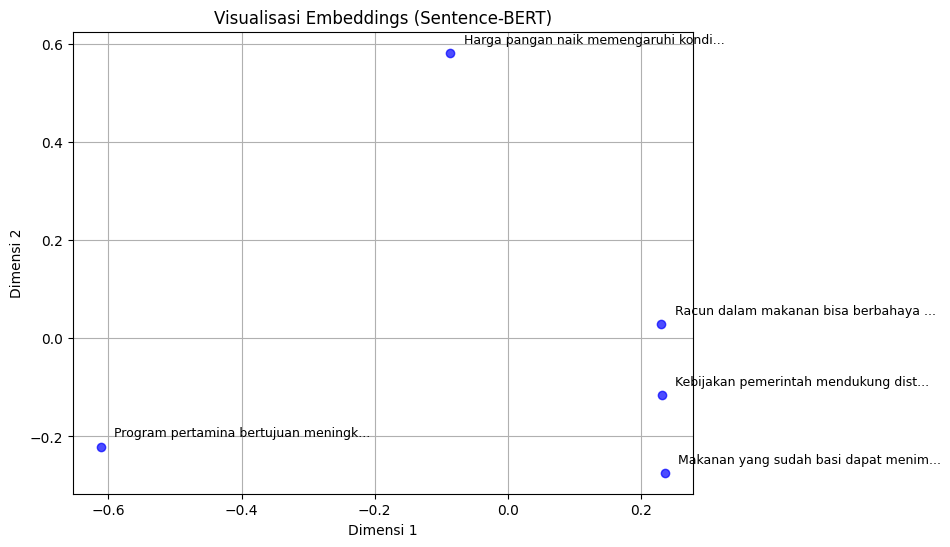

In [86]:
# --- 1. Install library jika belum ada ---
# pip install sentence-transformers scikit-learn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 2. Contoh kalimat (dengan kata 'basi' & 'racun' + topik pertamina) ---
sentences = [
    "Makanan yang sudah basi dapat menimbulkan penyakit.",
    "Racun dalam makanan bisa berbahaya bagi kesehatan.",
    "Program pertamina bertujuan meningkatkan gizi anak-anak.",
    "Kebijakan pemerintah mendukung distribusi makanan gratis.",
    "Harga pangan naik memengaruhi kondisi ekonomi keluarga."
]

# --- 3. Buat embeddings dengan model Sentence-BERT ---
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Ukuran embeddings:", embeddings.shape)  # contoh: (5, 384)

# --- 4. Reduksi dimensi ke 2D (PCA) ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

# --- 5. Plot hasil visualisasi ---
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue", alpha=0.7)

for i, text in enumerate(sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:35]+"...", fontsize=9)

plt.title("Visualisasi Embeddings (Sentence-BERT)")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()
